# 00 — Exploratory Data Analysis (EDA)

This notebook performs dataset-level exploratory analysis for the PhysioNet/CinC 2019 Sepsis Prediction dataset.

The project uses **one predefined training set**. Set `TRAINING_SET` below to the selected folder.

The purpose is to generate meaningful statistics and report-quality figures before preprocessing:
- patient and hourly-record counts
- sepsis prevalence
- patient/ICU sequence lengths
- sepsis-label onset timing
- missingness across clinical variables
- distributions of important clinical variables
- septic vs non-septic comparisons
- clinical correlations
- example patient trajectories

This notebook does **not** perform imputation, discretization, sequence mining, classification, or model training.

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Use ONE predefined training set.
TRAINING_SET = "training_setA"
INPUT_DIR = DATA_DIR / TRAINING_SET

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_DIR)
print("Output:", OUTPUT_DIR)


Input: E:\ssdproject\data\raw\training_setA
Output: E:\ssdproject\outputs\eda


## 2. Locate Patient Files

In [2]:
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {INPUT_DIR}")

psv_files = sorted(INPUT_DIR.glob("*.psv"))

if not psv_files:
    raise FileNotFoundError(f"No .psv files found in {INPUT_DIR}")

print(f"Patient files found: {len(psv_files):,}")
print("Examples:")
for path in psv_files[:5]:
    print(" ", path.name)


Patient files found: 20,336
Examples:
  p000001.psv
  p000002.psv
  p000003.psv
  p000004.psv
  p000005.psv


## 3. Inspect the Raw Schema

In [3]:
sample_df = pd.read_csv(psv_files[0], sep="|")

print("Example patient:", psv_files[0].name)
print("Rows:", f"{len(sample_df):,}")
print("Columns:", len(sample_df.columns))

display(sample_df.head())
display(pd.DataFrame({
    "column": sample_df.columns,
    "dtype": [sample_df[c].dtype for c in sample_df.columns]
}))


Example patient: p000001.psv
Rows: 54
Columns: 41


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


,column,dtype
0,HR,float64
1,O2Sat,float64
2,Temp,float64
3,SBP,float64
4,MAP,float64
5,DBP,float64
6,Resp,float64
7,EtCO2,float64
8,BaseExcess,float64
9,HCO3,float64


## 4. Build a Patient-Level Summary

In [4]:
def patient_summary(path):
    df = pd.read_csv(path, sep="|")
    labels = pd.to_numeric(df["SepsisLabel"], errors="coerce").fillna(0)
    positive = np.flatnonzero(labels.to_numpy() == 1)

    return {
        "patient_id": path.stem,
        "hours": len(df),
        "septic": int(len(positive) > 0),
        "sepsis_onset_hour": int(positive[0] + 1) if len(positive) else np.nan,
        "positive_hours": int((labels == 1).sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "total_cells": int(df.shape[0] * df.shape[1]),
    }

summaries = []
for i, path in enumerate(psv_files, start=1):
    summaries.append(patient_summary(path))
    if i % 1000 == 0 or i == len(psv_files):
        print(f"Processed {i:,}/{len(psv_files):,}")

patient_df = pd.DataFrame(summaries)
patient_df["missing_pct"] = 100 * patient_df["missing_cells"] / patient_df["total_cells"]

display(patient_df.head())
display(patient_df.describe())


Processed 1,000/20,336
Processed 2,000/20,336
Processed 3,000/20,336
Processed 4,000/20,336
Processed 5,000/20,336
Processed 6,000/20,336
Processed 7,000/20,336
Processed 8,000/20,336
Processed 9,000/20,336
Processed 10,000/20,336
Processed 11,000/20,336
Processed 12,000/20,336
Processed 13,000/20,336
Processed 14,000/20,336
Processed 15,000/20,336
Processed 16,000/20,336
Processed 17,000/20,336
Processed 18,000/20,336
Processed 19,000/20,336
Processed 20,000/20,336
Processed 20,336/20,336


,patient_id,hours,septic,sepsis_onset_hour,positive_hours,missing_cells,total_cells,missing_pct
0,p000001,54,0,NaN,0,1650,2214,74.525745
1,p000002,23,0,NaN,0,648,943,68.716861
2,p000003,48,0,NaN,0,1293,1968,65.701220
3,p000004,29,0,NaN,0,798,1189,67.115223
4,p000005,48,0,NaN,0,1466,1968,74.491870


,hours,septic,sepsis_onset_hour,positive_hours,missing_cells,total_cells,missing_pct
count,20336.000000,20336.000000,1790.000000,20336.000000,20336.000000,20336.000000,20336.000000
mean,38.857937,0.088021,50.065922,0.842644,1086.880360,1593.175403,68.241574
std,22.308659,0.283333,57.343113,2.718372,626.443527,914.655006,5.273907
min,8.000000,0.000000,1.000000,0.000000,156.000000,328.000000,38.211382
25%,25.000000,0.000000,8.000000,0.000000,695.750000,1025.000000,64.418298
50%,39.000000,0.000000,29.000000,0.000000,1076.000000,1599.000000,68.851626
75%,47.000000,0.000000,72.000000,0.000000,1323.000000,1927.000000,72.178276
max,336.000000,1.000000,331.000000,10.000000,9794.000000,13776.000000,87.521271


## 5. Dataset Overview

In [5]:
n_patients = len(patient_df)
n_septic = int(patient_df["septic"].sum())
n_nonseptic = n_patients - n_septic
total_hours = int(patient_df["hours"].sum())

overview = pd.DataFrame({
    "Metric": [
        "Patient files",
        "Septic patients",
        "Non-septic patients",
        "Total hourly records",
        "Sepsis patient percentage",
        "Median patient sequence length",
    ],
    "Value": [
        n_patients,
        n_septic,
        n_nonseptic,
        total_hours,
        100 * n_septic / n_patients,
        patient_df["hours"].median(),
    ]
})

display(overview)


,Metric,Value
0,Patient files,20336.000000
1,Septic patients,1790.000000
2,Non-septic patients,18546.000000
3,Total hourly records,790215.000000
4,Sepsis patient percentage,8.802124
5,Median patient sequence length,39.000000


## 6. Sepsis vs Non-Sepsis Patient Distribution

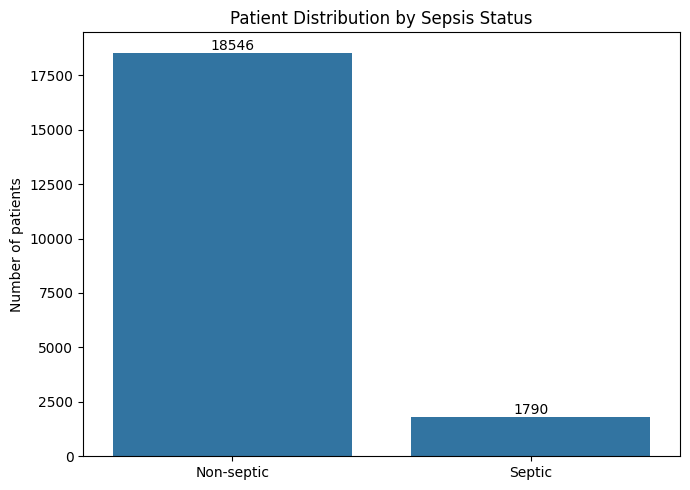

In [6]:
plot_df = pd.DataFrame({
    "Group": ["Non-septic", "Septic"],
    "Patients": [n_nonseptic, n_septic]
})

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=plot_df, x="Group", y="Patients")
ax.set_title("Patient Distribution by Sepsis Status")
ax.set_xlabel("")
ax.set_ylabel("Number of patients")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_sepsis_patient_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Patient Sequence-Length Distribution

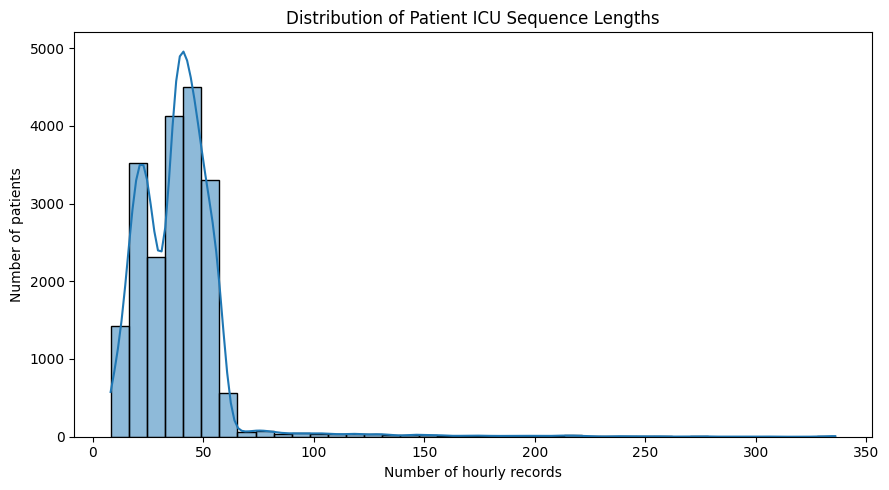

count    20336.000000
mean        38.857937
std         22.308659
min          8.000000
25%         25.000000
50%         39.000000
75%         47.000000
max        336.000000
Name: hours, dtype: float64

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(patient_df["hours"], bins=40, kde=True)
plt.title("Distribution of Patient ICU Sequence Lengths")
plt.xlabel("Number of hourly records")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_patient_sequence_lengths.png", dpi=300, bbox_inches="tight")
plt.show()

display(patient_df["hours"].describe())


## 8. Sequence Length by Sepsis Status

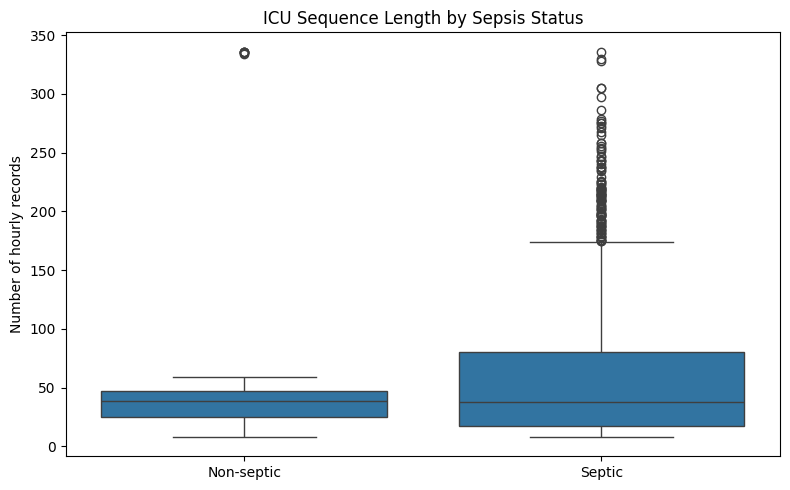

In [8]:
plot_df = patient_df.copy()
plot_df["Sepsis status"] = plot_df["septic"].map({0: "Non-septic", 1: "Septic"})

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x="Sepsis status", y="hours")
plt.title("ICU Sequence Length by Sepsis Status")
plt.xlabel("")
plt.ylabel("Number of hourly records")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_sequence_length_by_sepsis.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Sepsis-Label Onset Distribution

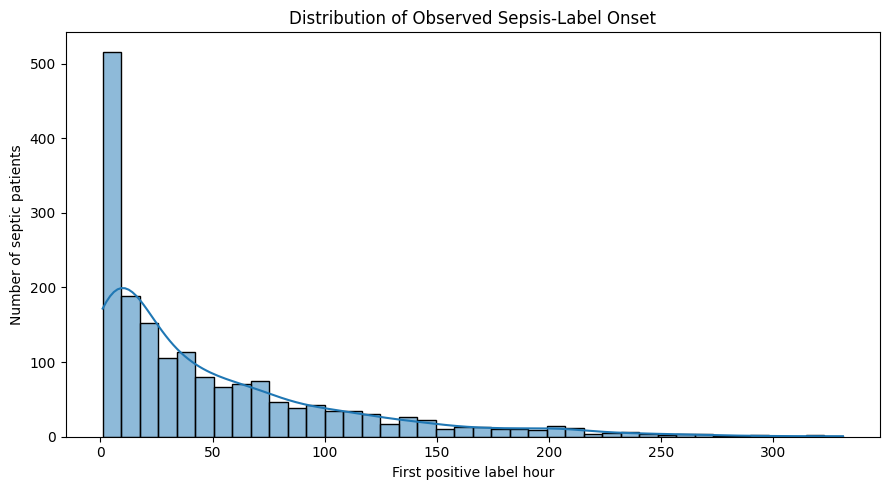

count    1790.000000
mean       50.065922
std        57.343113
min         1.000000
25%         8.000000
50%        29.000000
75%        72.000000
max       331.000000
Name: sepsis_onset_hour, dtype: float64

In [9]:
onset_df = patient_df.dropna(subset=["sepsis_onset_hour"])

plt.figure(figsize=(9, 5))
sns.histplot(onset_df["sepsis_onset_hour"], bins=40, kde=True)
plt.title("Distribution of Observed Sepsis-Label Onset")
plt.xlabel("First positive label hour")
plt.ylabel("Number of septic patients")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_sepsis_onset_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

display(onset_df["sepsis_onset_hour"].describe())


## 10. Positive-Label Hours Across Septic Patients

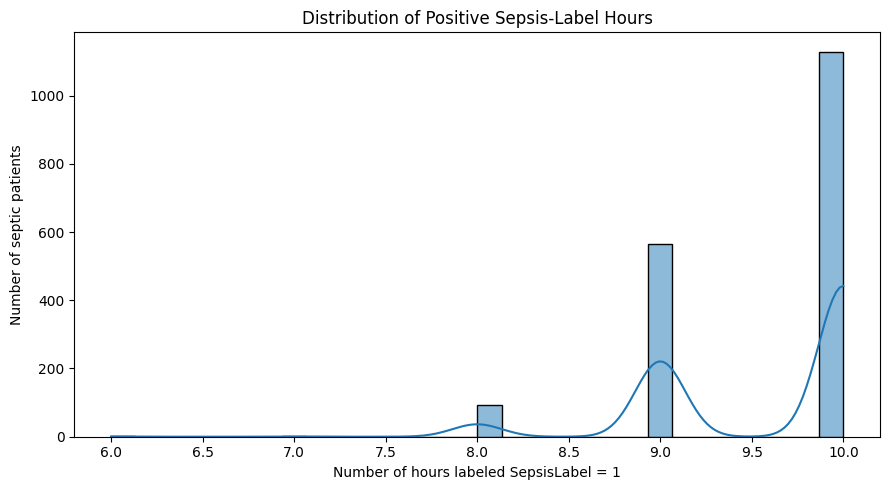

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(onset_df["positive_hours"], bins=30, kde=True)
plt.title("Distribution of Positive Sepsis-Label Hours")
plt.xlabel("Number of hours labeled SepsisLabel = 1")
plt.ylabel("Number of septic patients")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_positive_label_hours.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Missingness Across Clinical Variables

In [11]:
missing_counts = {}
total_counts = {}

for i, path in enumerate(psv_files, start=1):
    df = pd.read_csv(path, sep="|")
    for col in df.columns:
        missing_counts[col] = missing_counts.get(col, 0) + int(df[col].isna().sum())
        total_counts[col] = total_counts.get(col, 0) + len(df)

missingness = pd.DataFrame({
    "Variable": list(total_counts.keys()),
    "Missing": [missing_counts[c] for c in total_counts],
    "Observed": [total_counts[c] - missing_counts[c] for c in total_counts],
})
missingness["Missing %"] = 100 * missingness["Missing"] / (
    missingness["Missing"] + missingness["Observed"]
)
missingness = missingness.sort_values("Missing %", ascending=False)

display(missingness)
missingness.to_csv(OUTPUT_DIR / "missingness_summary.csv", index=False)


,Variable,Missing,Observed,Missing %
7,EtCO2,790215,0,100.000000
27,TroponinI,789250,965,99.877881
20,Bilirubin_direct,789033,1182,99.850420
32,Fibrinogen,784185,6030,99.236917
26,Bilirubin_total,780522,9693,98.773372
16,Alkalinephos,778683,11532,98.540650
14,AST,778395,11820,98.504205
22,Lactate,763072,27143,96.565112
30,PTT,751909,38306,95.152459
13,SaO2,751055,39160,95.044387


## 12. Missingness Bar Chart — All Variables

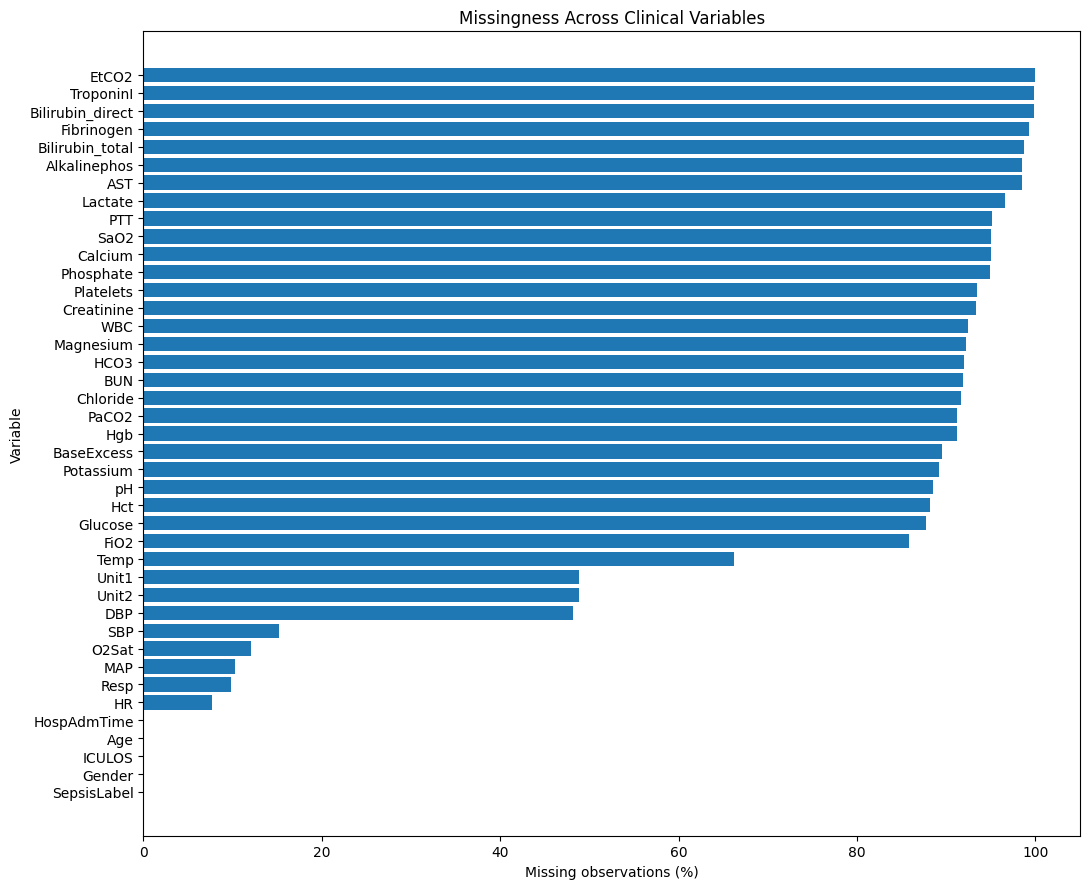

In [12]:
plot_df = missingness.sort_values("Missing %", ascending=True)

plt.figure(figsize=(11, 9))
plt.barh(plot_df["Variable"], plot_df["Missing %"])
plt.title("Missingness Across Clinical Variables")
plt.xlabel("Missing observations (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_missingness_all_variables.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Missingness Heatmap for an Example Patient

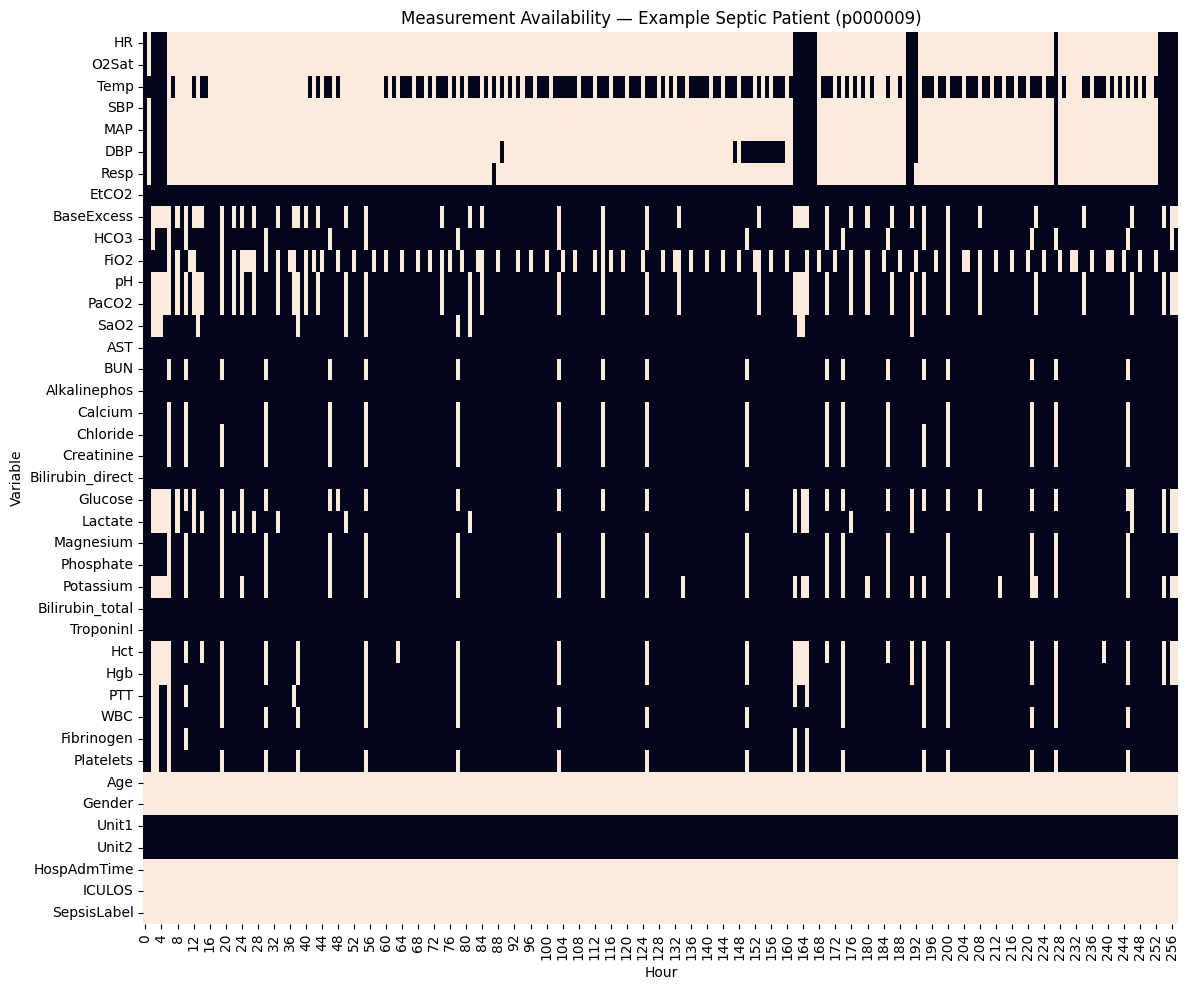

In [13]:
septic_example_path = None

for path in psv_files:
    df = pd.read_csv(path, sep="|")
    labels = pd.to_numeric(df["SepsisLabel"], errors="coerce").fillna(0)
    if (labels == 1).any():
        septic_example_path = path
        break

if septic_example_path is not None:
    example = pd.read_csv(septic_example_path, sep="|")
    availability = (~example.isna()).astype(int).T

    plt.figure(figsize=(12, 10))
    sns.heatmap(availability, cbar=False)
    plt.title(f"Measurement Availability — Example Septic Patient ({septic_example_path.stem})")
    plt.xlabel("Hour")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "07_example_patient_missingness_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No septic patient found.")


## 14. Important Clinical Variable Distributions

In [14]:
PLOT_VARIABLES = [
    c for c in ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "Lactate", "WBC"]
    if c in sample_df.columns
]

print("Variables:", PLOT_VARIABLES)


Variables: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Lactate', 'WBC']


In [15]:
MAX_VALUES_PER_VARIABLE = 100_000
rng = np.random.default_rng(RANDOM_SEED)
value_samples = {c: [] for c in PLOT_VARIABLES}

for path in psv_files:
    df = pd.read_csv(path, sep="|", usecols=lambda c: c in PLOT_VARIABLES)
    for col in PLOT_VARIABLES:
        values = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy()
        if len(values):
            value_samples[col].extend(values.tolist())

for col in PLOT_VARIABLES:
    values = np.asarray(value_samples[col])
    if len(values) > MAX_VALUES_PER_VARIABLE:
        value_samples[col] = rng.choice(values, MAX_VALUES_PER_VARIABLE, replace=False)
    else:
        value_samples[col] = values

distribution_summary = pd.DataFrame({
    "Variable": PLOT_VARIABLES,
    "Observed values": [len(value_samples[c]) for c in PLOT_VARIABLES],
    "Median": [np.median(value_samples[c]) for c in PLOT_VARIABLES],
    "Mean": [np.mean(value_samples[c]) for c in PLOT_VARIABLES],
})
display(distribution_summary)


,Variable,Observed values,Median,Mean
0,HR,100000,84.00,85.045451
1,O2Sat,100000,98.00,97.263836
2,Temp,100000,37.06,37.025906
3,SBP,100000,118.50,120.951286
4,MAP,100000,77.00,78.797404
5,DBP,100000,58.50,59.941657
6,Resp,100000,18.00,18.787157
7,Lactate,27143,1.80,2.469203
8,WBC,59348,10.80,11.936604


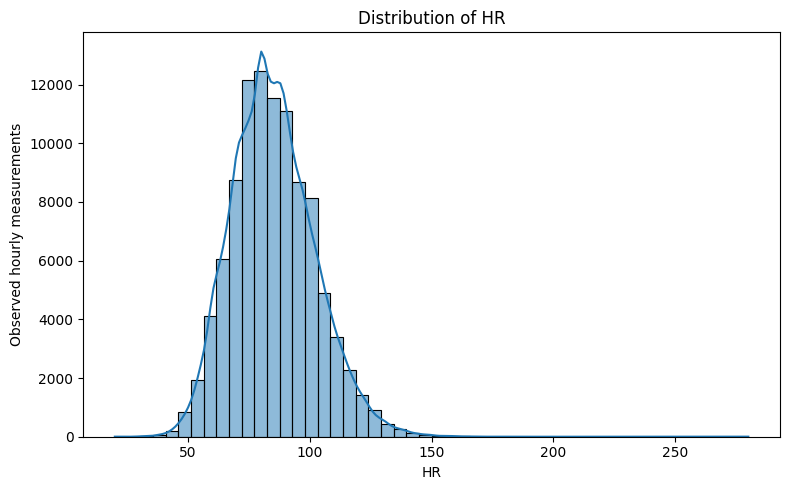

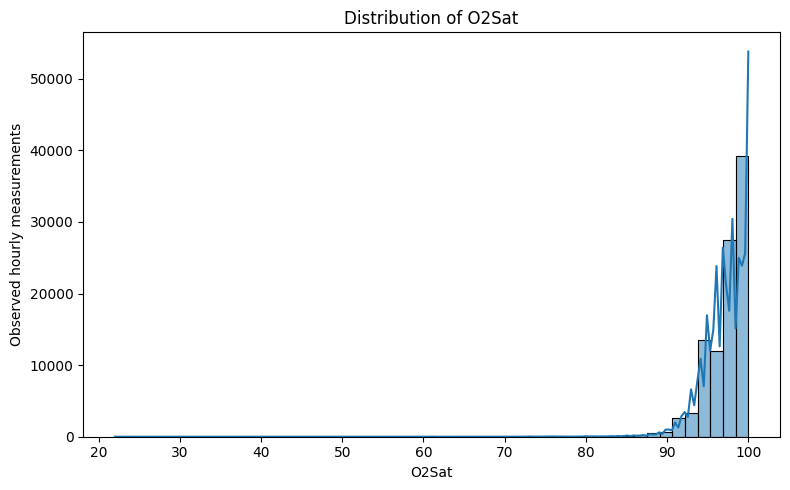

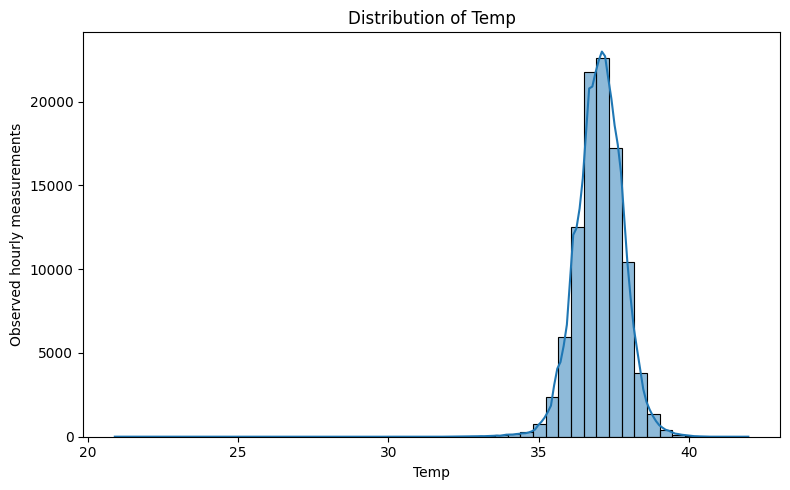

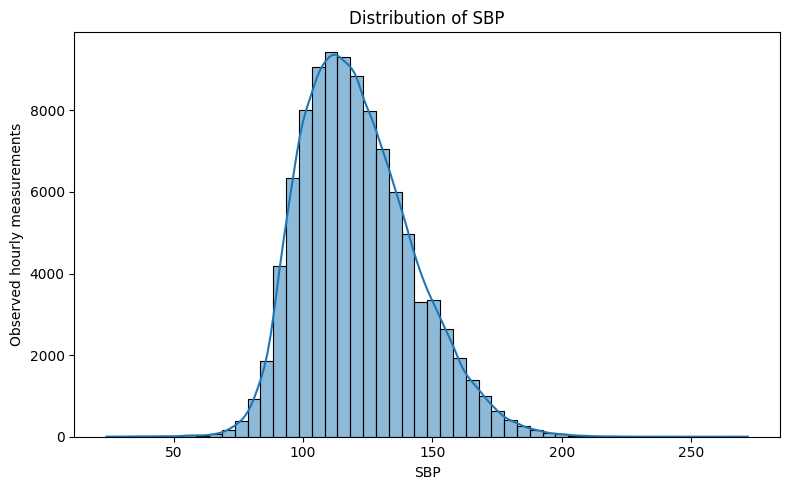

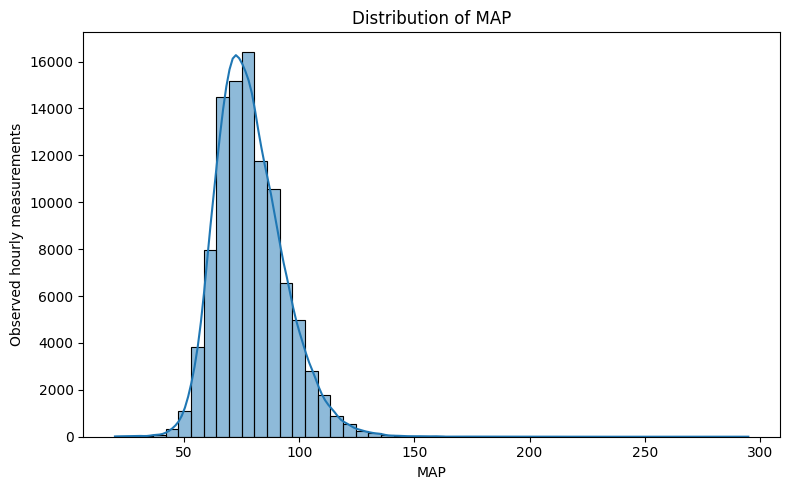

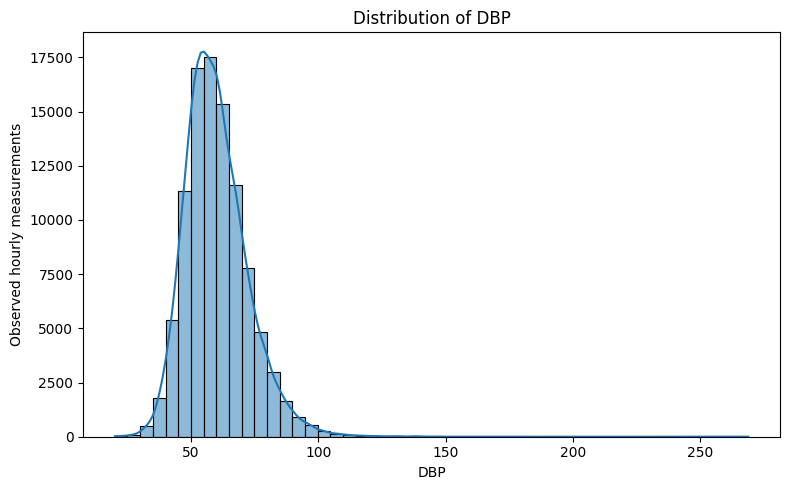

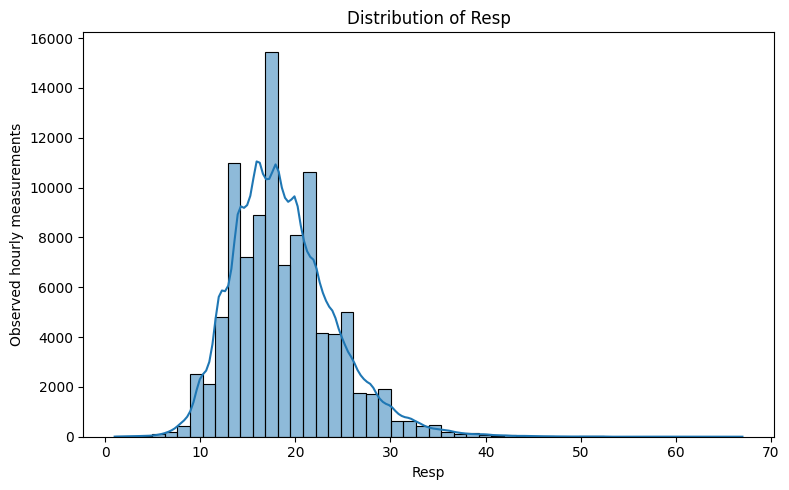

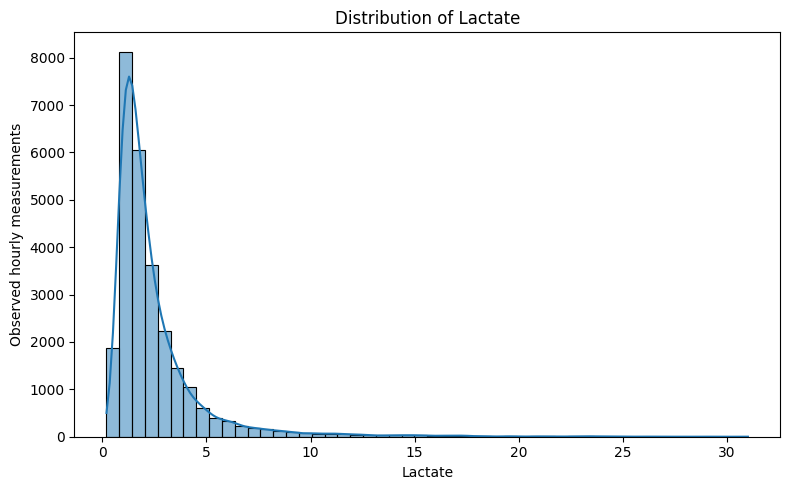

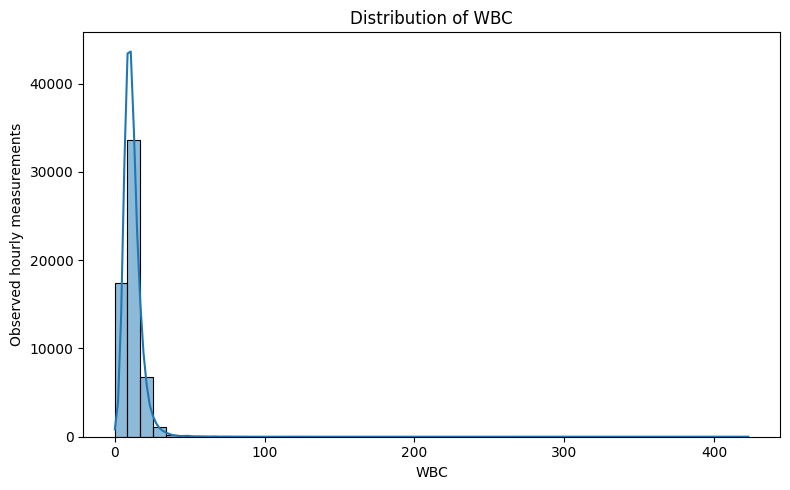

In [16]:
for col in PLOT_VARIABLES:
    plt.figure(figsize=(8, 5))
    sns.histplot(value_samples[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Observed hourly measurements")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"08_distribution_{col.replace('/', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()


## 15. Correlation Between Selected Clinical Variables

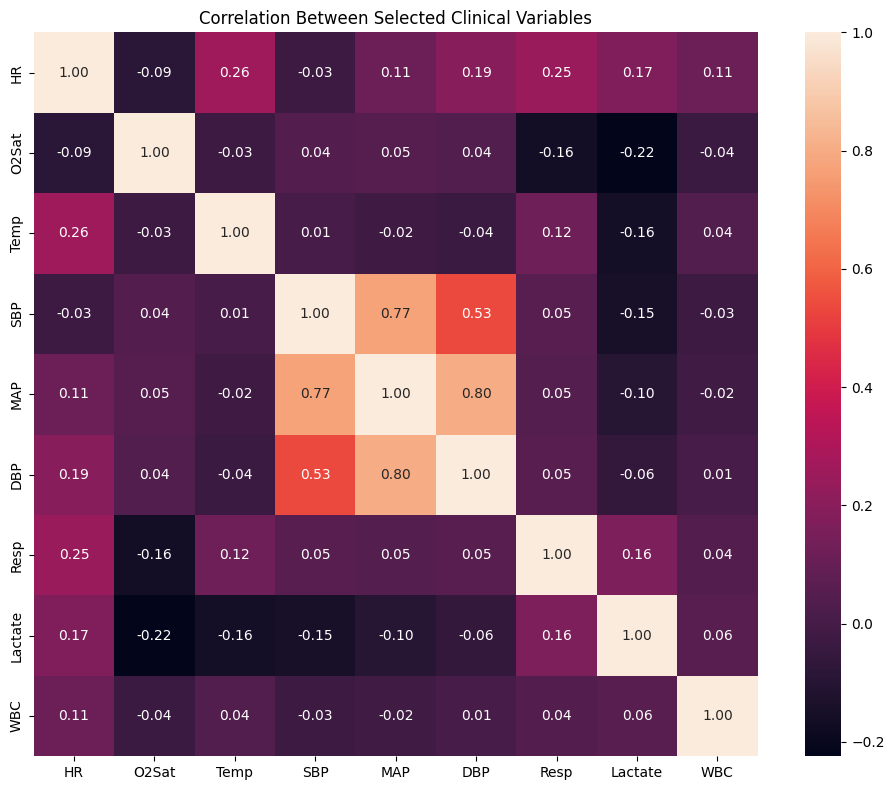

In [17]:
corr_frames = []

for path in psv_files:
    df = pd.read_csv(path, sep="|", usecols=lambda c: c in PLOT_VARIABLES)
    corr_frames.append(df[PLOT_VARIABLES])

corr_sample = pd.concat(corr_frames, ignore_index=True)

if len(corr_sample) > 100_000:
    corr_sample = corr_sample.sample(100_000, random_state=RANDOM_SEED)

corr_matrix = corr_sample.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", square=True)
plt.title("Correlation Between Selected Clinical Variables")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_clinical_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 16. Septic vs Non-Septic Clinical Distributions

In [18]:
comparison_frames = []

for path in psv_files:
    df = pd.read_csv(path, sep="|")
    label = pd.to_numeric(df["SepsisLabel"], errors="coerce").fillna(0)
    patient_status = int((label == 1).any())

    available = [c for c in PLOT_VARIABLES if c in df.columns]
    part = df[available].copy()
    part["Sepsis status"] = "Septic" if patient_status else "Non-septic"
    comparison_frames.append(part)

comparison_df = pd.concat(comparison_frames, ignore_index=True)

if len(comparison_df) > 150_000:
    comparison_df = comparison_df.sample(150_000, random_state=RANDOM_SEED)

print(comparison_df.groupby("Sepsis status").size())


Sepsis status
Non-septic    129948
Septic         20052
dtype: int64


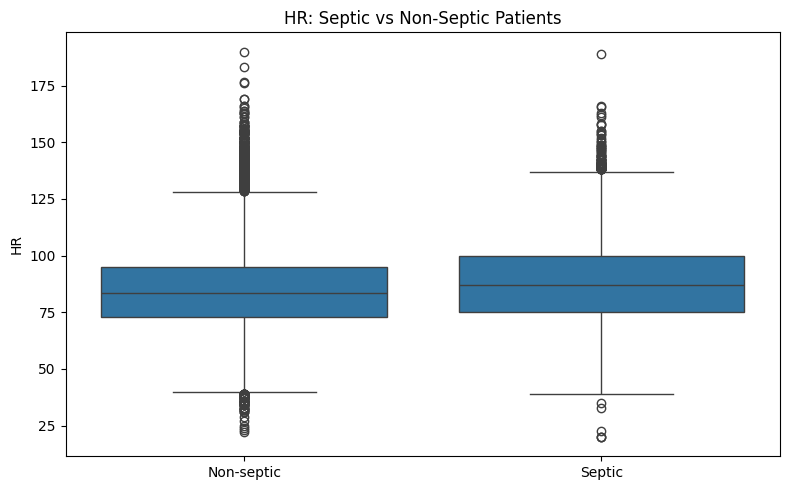

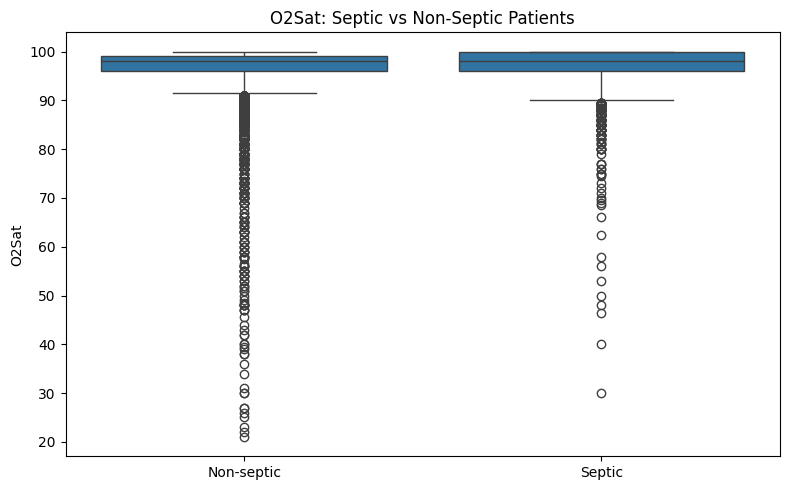

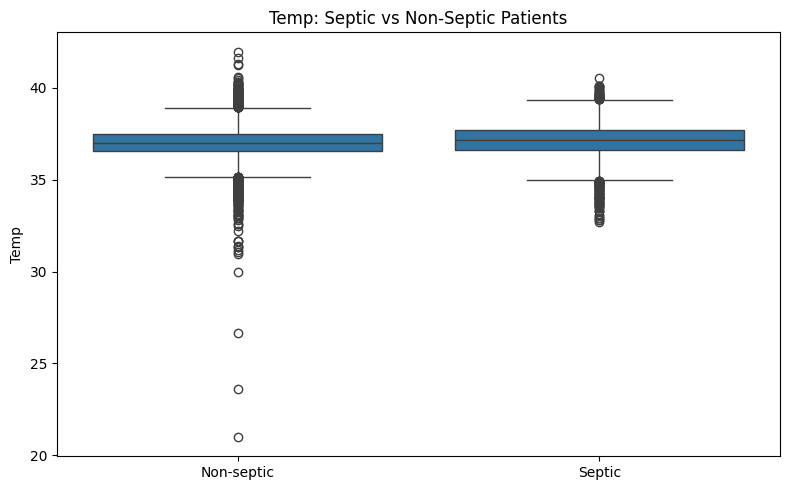

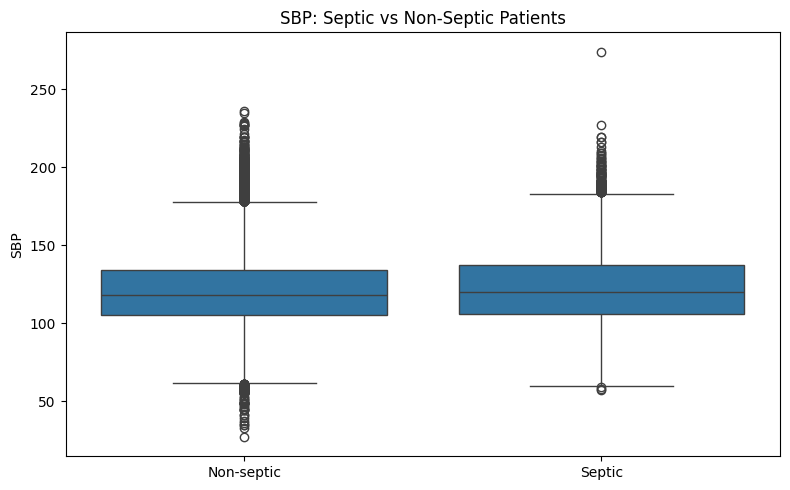

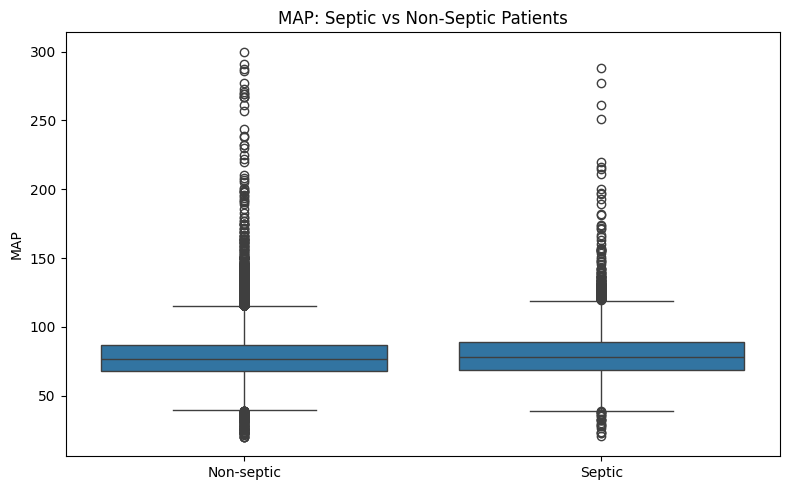

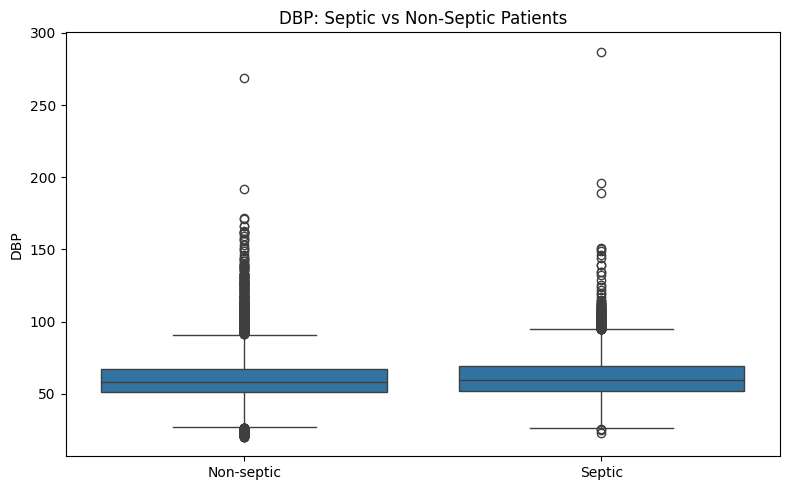

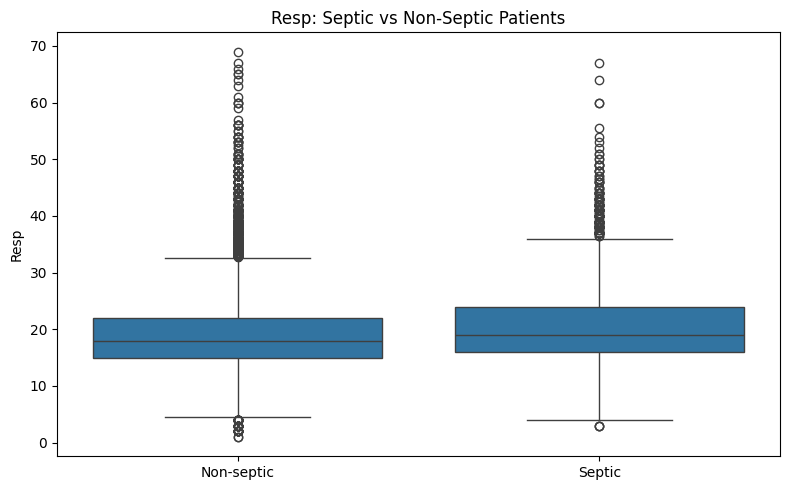

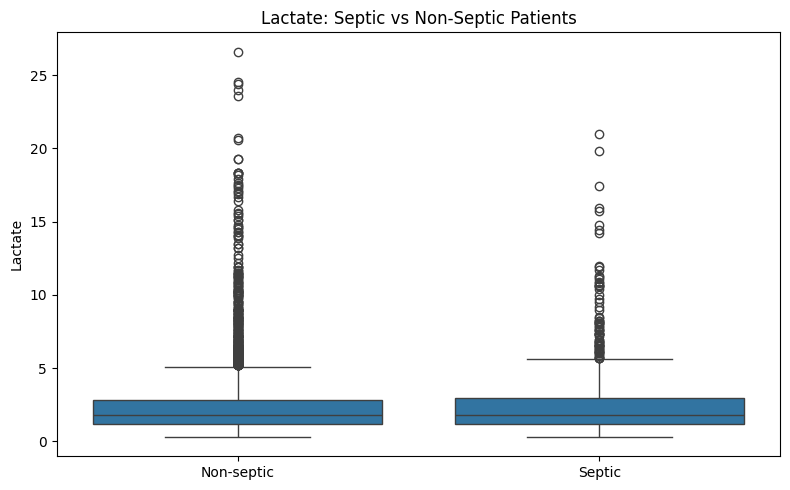

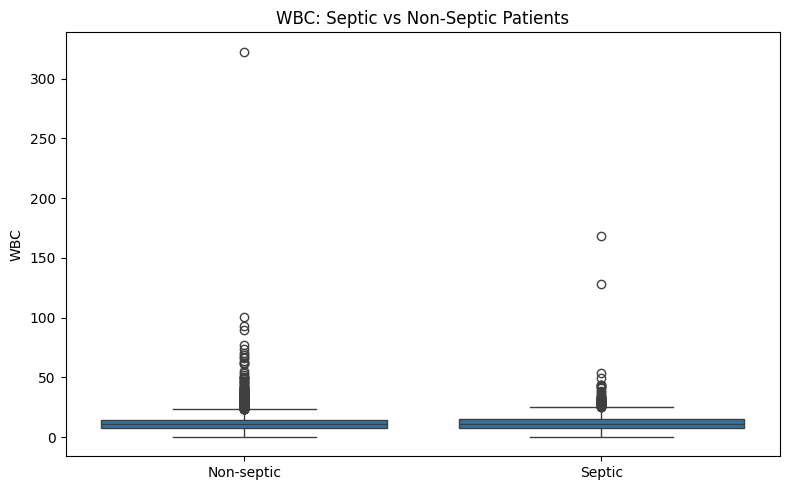

In [19]:
for col in PLOT_VARIABLES:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=comparison_df, x="Sepsis status", y=col)
    plt.title(f"{col}: Septic vs Non-Septic Patients")
    plt.xlabel("")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"10_septic_vs_nonseptic_{col.replace('/', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()


## 17. Example Patient Trajectories

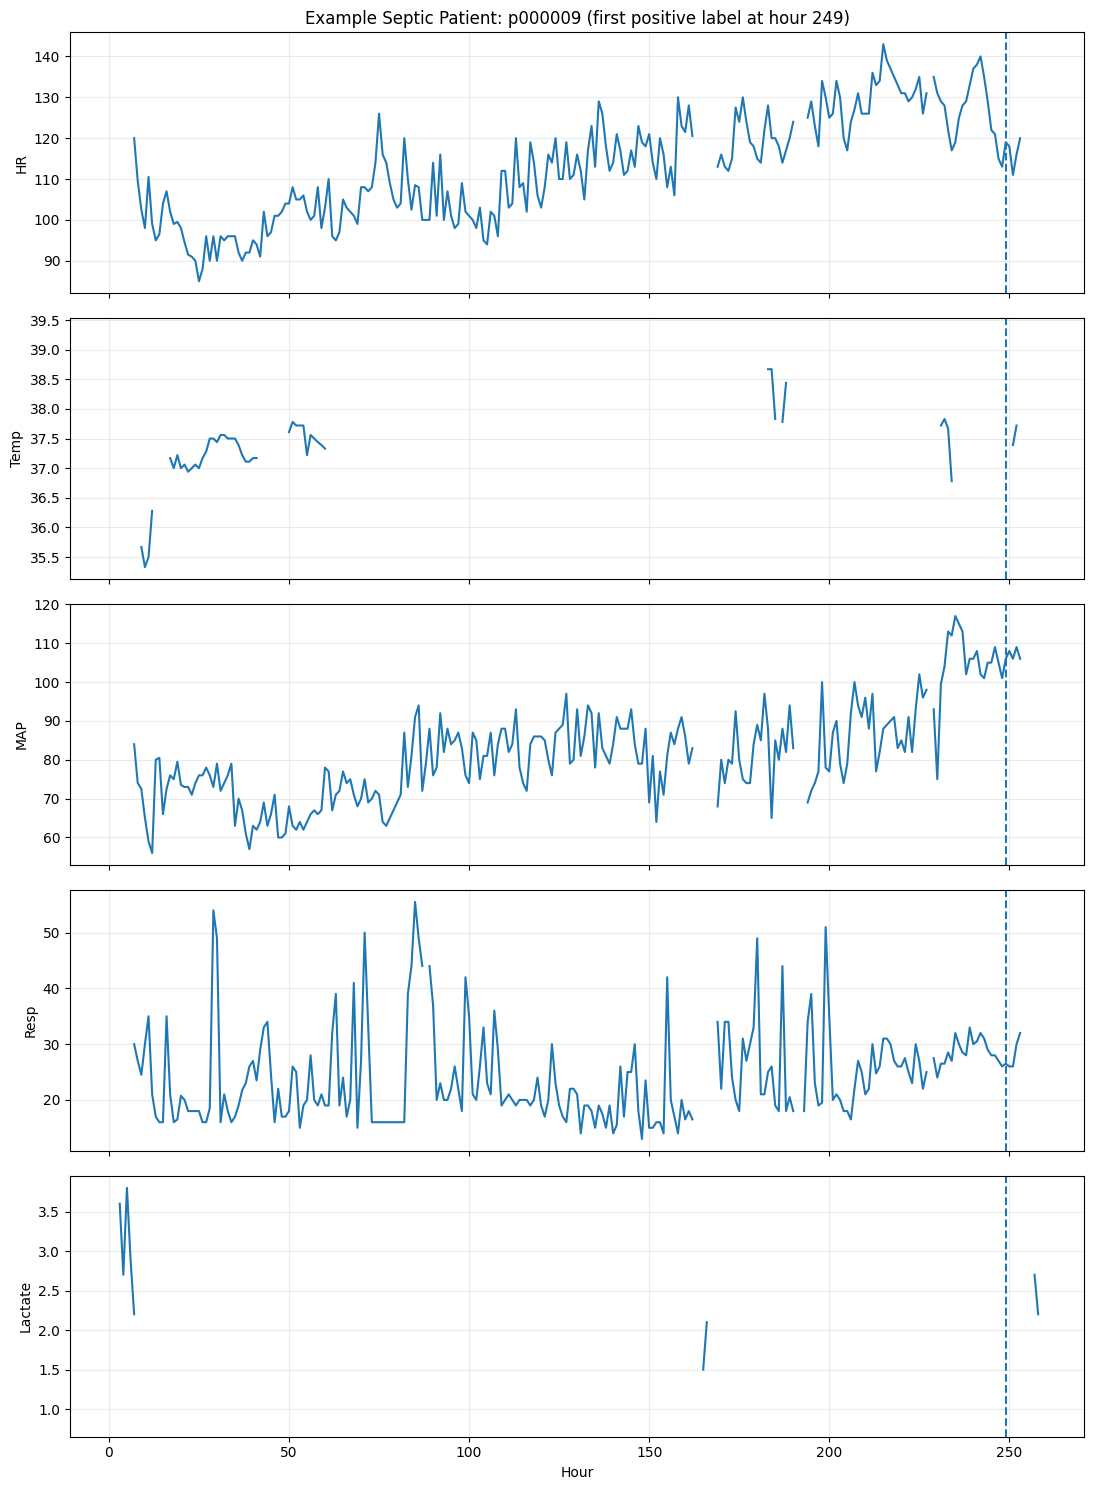

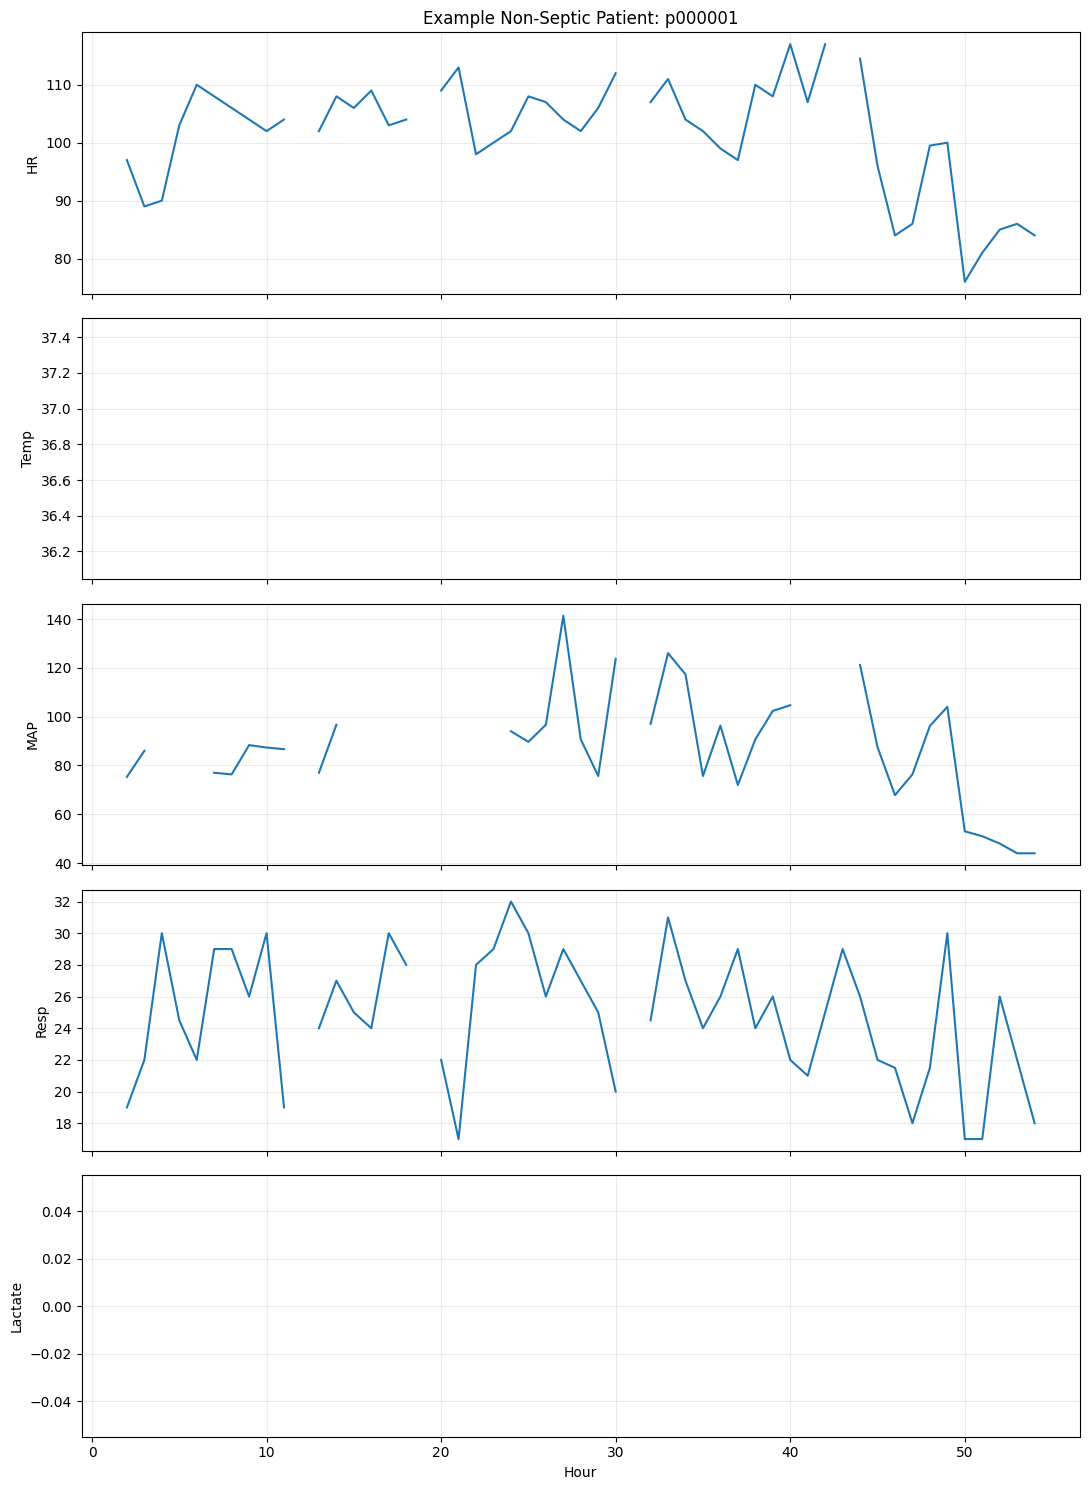

In [20]:
def find_example_patient(require_sepsis=True):
    for path in psv_files:
        df = pd.read_csv(path, sep="|")
        labels = pd.to_numeric(df["SepsisLabel"], errors="coerce").fillna(0)
        if bool((labels == 1).any()) == require_sepsis:
            return path
    return None

def plot_patient_trajectory(path, variables):
    df = pd.read_csv(path, sep="|")
    fig, axes = plt.subplots(len(variables), 1, figsize=(11, 3 * len(variables)), sharex=True)
    if len(variables) == 1:
        axes = [axes]

    for ax, col in zip(axes, variables):
        ax.plot(df.index + 1, pd.to_numeric(df[col], errors="coerce"))
        ax.set_ylabel(col)
        ax.grid(alpha=0.25)

    labels = pd.to_numeric(df["SepsisLabel"], errors="coerce").fillna(0)
    positive = np.flatnonzero(labels.to_numpy() == 1)

    if len(positive):
        onset = positive[0] + 1
        for ax in axes:
            ax.axvline(onset, linestyle="--")
        axes[0].set_title(
            f"Example Septic Patient: {path.stem} "
            f"(first positive label at hour {onset})"
        )
    else:
        axes[0].set_title(f"Example Non-Septic Patient: {path.stem}")

    axes[-1].set_xlabel("Hour")
    fig.tight_layout()
    return fig

trajectory_variables = [
    c for c in ["HR", "Temp", "MAP", "Resp", "Lactate"]
    if c in sample_df.columns
]

septic_path = find_example_patient(True)
nonseptic_path = find_example_patient(False)

if septic_path:
    fig = plot_patient_trajectory(septic_path, trajectory_variables)
    fig.savefig(OUTPUT_DIR / "11_example_septic_trajectory.png", dpi=300, bbox_inches="tight")
    plt.show()

if nonseptic_path:
    fig = plot_patient_trajectory(nonseptic_path, trajectory_variables)
    fig.savefig(OUTPUT_DIR / "12_example_nonseptic_trajectory.png", dpi=300, bbox_inches="tight")
    plt.show()


## 18. Export EDA Tables

In [21]:
patient_df.to_csv(OUTPUT_DIR / "patient_summary.csv", index=False)
overview.to_csv(OUTPUT_DIR / "dataset_overview.csv", index=False)
distribution_summary.to_csv(OUTPUT_DIR / "clinical_distribution_summary.csv", index=False)

print("EDA tables and figures saved to:")
print(OUTPUT_DIR)


EDA tables and figures saved to:
E:\ssdproject\outputs\eda


## EDA Takeaways

After running the notebook, base the report discussion on the actual generated statistics and figures.

The EDA should establish:
1. The scale of the selected training set.
2. The degree of sepsis class imbalance.
3. Variation in ICU sequence lengths.
4. Timing of observed sepsis labels.
5. The extent of missing clinical measurements.
6. Distributions of important physiological/laboratory variables.
7. Differences between septic and non-septic patient populations.
8. Example temporal trajectories motivating sequential pattern mining.

Do not write numerical conclusions before executing the notebook on the actual dataset.